In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!nvidia-smi

Mon May 18 08:34:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   30C    P0             47W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 35.5 MB/s eta 0:00:00


In [4]:
from pathlib import Path
import pandas as pd
from collections import Counter
import shutil
import random
from PIL import Image
import matplotlib.pyplot as plt

from ultralytics import YOLO

BASE_DIR = Path("/content/drive/MyDrive/DIS_PROJESI_007")

ALPHADENT_DATASET = BASE_DIR / "data_prepared" / "alphadent_yolo_seg_2class"
DATA_YAML = ALPHADENT_DATASET / "data.yaml"

RUNS_DIR = BASE_DIR / "runs" / "alphadent"
RESULTS_DIR = BASE_DIR / "results" / "alphadent_training"
FINAL_MODELS_DIR = BASE_DIR / "final_models" / "alphadent"

RUNS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FINAL_MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("AlphaDent dataset:", ALPHADENT_DATASET)
print("data.yaml:", DATA_YAML)
print("data.yaml var mı?:", DATA_YAML.exists())
print("RUNS_DIR:", RUNS_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("FINAL_MODELS_DIR:", FINAL_MODELS_DIR)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
AlphaDent dataset: /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_yolo_seg_2class
data.yaml: /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_yolo_seg_2class/data.yaml
data.yaml var mı?: True
RUNS_DIR: /content/drive/MyDrive/DIS_PROJESI_007/runs/alphadent
RESULTS_DIR: /content/drive/MyDrive/DIS_PROJESI_007/results/alphadent_training
FINAL_MODELS_DIR: /content/drive/MyDrive/DIS_PROJESI_007/final_models/alphadent


In [5]:
print(DATA_YAML.read_text())

path: /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_yolo_seg_2class
train: images/train
val: images/val

names:
  0: dis_asinmasi
  1: dis_curugu


In [6]:
def count_split(split):
    img_dir = ALPHADENT_DATASET / "images" / split
    label_dir = ALPHADENT_DATASET / "labels" / split

    img_count = len(list(img_dir.glob("*")))
    label_count = len(list(label_dir.glob("*.txt")))

    return img_count, label_count

rows = []

for split in ["train", "val"]:
    img_count, label_count = count_split(split)
    rows.append({
        "split": split,
        "images": img_count,
        "labels": label_count
    })

df_split_counts = pd.DataFrame(rows)
df_split_counts

,split,images,labels
0,train,1208,1208
1,val,82,82


In [7]:
class_names = {
    0: "dis_asinmasi",
    1: "dis_curugu"
}

counter = Counter()

label_dirs = [
    ALPHADENT_DATASET / "labels" / "train",
    ALPHADENT_DATASET / "labels" / "val"
]

label_paths = []

for label_dir in label_dirs:
    label_paths.extend(list(label_dir.glob("*.txt")))

print("Toplam label dosyası:", len(label_paths))

for label_path in label_paths:
    lines = label_path.read_text(errors="ignore").strip().splitlines()

    for line in lines:
        if line.strip() == "":
            continue

        cls_id = int(float(line.split()[0]))
        counter[cls_id] += 1

df_class_counts = pd.DataFrame([
    {
        "class_id": cls_id,
        "class_name": class_names.get(cls_id, f"class_{cls_id}"),
        "count": count
    }
    for cls_id, count in sorted(counter.items())
])

df_class_counts

Toplam label dosyası: 1290


,class_id,class_name,count
0,0,dis_asinmasi,6347
1,1,dis_curugu,3563


In [8]:
first_round_csv = RESULTS_DIR / "alphadent_seg_model_comparison_first_round_30ep.csv"

print("İlk tur CSV:", first_round_csv)
print("Var mı?:", first_round_csv.exists())

if first_round_csv.exists():
    df_first_round = pd.read_csv(first_round_csv)
else:
    print("CSV bulunamadı. Manuel tablo oluşturulacak.")
    df_first_round = pd.DataFrame([
        {
            "status": "ok",
            "model": "YOLOv8n-seg",
            "weights": "yolov8n-seg.pt",
            "run_name": "yolov8n_seg_640_30ep",
            "imgsz": 640,
            "epochs": 30,
            "batch": 8,
            "box_precision": 0.553011,
            "box_recall": 0.600889,
            "box_mAP50": 0.592514,
            "box_mAP50-95": 0.435657,
            "mask_precision": 0.559407,
            "mask_recall": 0.602827,
            "mask_mAP50": 0.589347,
            "mask_mAP50-95": 0.391522,
            "best_model_path": str(RUNS_DIR / "yolov8n_seg_640_30ep" / "weights" / "best.pt"),
            "error": ""
        },
        {
            "status": "ok",
            "model": "YOLOv8s-seg",
            "weights": "yolov8s-seg.pt",
            "run_name": "yolov8s_seg_640_30ep",
            "imgsz": 640,
            "epochs": 30,
            "batch": 8,
            "box_precision": 0.569006,
            "box_recall": 0.620811,
            "box_mAP50": 0.605136,
            "box_mAP50-95": 0.439920,
            "mask_precision": 0.563801,
            "mask_recall": 0.622749,
            "mask_mAP50": 0.582481,
            "mask_mAP50-95": 0.390327,
            "best_model_path": str(RUNS_DIR / "yolov8s_seg_640_30ep" / "weights" / "best.pt"),
            "error": ""
        },
        {
            "status": "ok",
            "model": "YOLOv8m-seg",
            "weights": "yolov8m-seg.pt",
            "run_name": "yolov8m_seg_640_30ep",
            "imgsz": 640,
            "epochs": 30,
            "batch": 4,
            "box_precision": 0.578482,
            "box_recall": 0.623575,
            "box_mAP50": 0.620584,
            "box_mAP50-95": 0.459795,
            "mask_precision": 0.613126,
            "mask_recall": 0.585585,
            "mask_mAP50": 0.612124,
            "mask_mAP50-95": 0.411457,
            "best_model_path": str(RUNS_DIR / "yolov8m_seg_640_30ep" / "weights" / "best.pt"),
            "error": ""
        },
        {
            "status": "ok",
            "model": "YOLO11s-seg",
            "weights": "yolo11s-seg.pt",
            "run_name": "yolo11s_seg_640_30ep",
            "imgsz": 640,
            "epochs": 30,
            "batch": 8,
            "box_precision": 0.558936,
            "box_recall": 0.588657,
            "box_mAP50": 0.601638,
            "box_mAP50-95": 0.438696,
            "mask_precision": 0.531689,
            "mask_recall": 0.605506,
            "mask_mAP50": 0.593423,
            "mask_mAP50-95": 0.395781,
            "best_model_path": str(RUNS_DIR / "yolo11s_seg_640_30ep" / "weights" / "best.pt"),
            "error": ""
        }
    ])

df_first_round

İlk tur CSV: /content/drive/MyDrive/DIS_PROJESI_007/results/alphadent_training/alphadent_seg_model_comparison_first_round_30ep.csv
Var mı?: True


,status,model,weights,run_name,imgsz,epochs,batch,box_precision,box_recall,box_mAP50,box_mAP50-95,mask_precision,mask_recall,mask_mAP50,mask_mAP50-95,best_model_path,error
0,ok,YOLOv8m-seg,yolov8m-seg.pt,yolov8m_seg_640_30ep,640,30,4,0.578482,0.623575,0.620584,0.459795,0.613126,0.585585,0.612124,0.411457,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,NaN
1,ok,YOLO11s-seg,yolo11s-seg.pt,yolo11s_seg_640_30ep,640,30,8,0.558936,0.588657,0.601638,0.438696,0.531689,0.605506,0.593423,0.395781,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,NaN
2,ok,YOLOv8n-seg,yolov8n-seg.pt,yolov8n_seg_640_30ep,640,30,8,0.553011,0.600889,0.592514,0.435657,0.559407,0.602827,0.589347,0.391522,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,NaN
3,ok,YOLOv8s-seg,yolov8s-seg.pt,yolov8s_seg_640_30ep,640,30,8,0.569006,0.620811,0.605136,0.439920,0.563801,0.622749,0.582481,0.390327,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,NaN


In [9]:
df_first_round_success = df_first_round[df_first_round["status"] == "ok"].copy()

df_first_round_sorted = df_first_round_success.sort_values(
    "mask_mAP50",
    ascending=False
).reset_index(drop=True)

df_first_round_sorted

,status,model,weights,run_name,imgsz,epochs,batch,box_precision,box_recall,box_mAP50,box_mAP50-95,mask_precision,mask_recall,mask_mAP50,mask_mAP50-95,best_model_path,error
0,ok,YOLOv8m-seg,yolov8m-seg.pt,yolov8m_seg_640_30ep,640,30,4,0.578482,0.623575,0.620584,0.459795,0.613126,0.585585,0.612124,0.411457,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,NaN
1,ok,YOLO11s-seg,yolo11s-seg.pt,yolo11s_seg_640_30ep,640,30,8,0.558936,0.588657,0.601638,0.438696,0.531689,0.605506,0.593423,0.395781,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,NaN
2,ok,YOLOv8n-seg,yolov8n-seg.pt,yolov8n_seg_640_30ep,640,30,8,0.553011,0.600889,0.592514,0.435657,0.559407,0.602827,0.589347,0.391522,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,NaN
3,ok,YOLOv8s-seg,yolov8s-seg.pt,yolov8s_seg_640_30ep,640,30,8,0.569006,0.620811,0.605136,0.439920,0.563801,0.622749,0.582481,0.390327,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,NaN


In [10]:
best_first_row = df_first_round_sorted.iloc[0]

best_first_model_name = best_first_row["model"]
best_first_run_name = best_first_row["run_name"]
best_first_model_path = Path(best_first_row["best_model_path"])

print("İlk tur en iyi AlphaDent modeli:")
print("Model:", best_first_model_name)
print("Run:", best_first_run_name)
print("Box mAP50:", best_first_row["box_mAP50"])
print("Box mAP50-95:", best_first_row["box_mAP50-95"])
print("Mask mAP50:", best_first_row["mask_mAP50"])
print("Mask mAP50-95:", best_first_row["mask_mAP50-95"])
print("Best model path:", best_first_model_path)
print("Var mı?:", best_first_model_path.exists())

İlk tur en iyi AlphaDent modeli:
Model: YOLOv8m-seg
Run: yolov8m_seg_640_30ep
Box mAP50: 0.6205839096229581
Box mAP50-95: 0.4597950177135838
Mask mAP50: 0.612123561256956
Mask mAP50-95: 0.4114572713462247
Best model path: /content/drive/MyDrive/DIS_PROJESI_007/runs/alphadent/yolov8m_seg_640_30ep/weights/best.pt
Var mı?: True


In [11]:
final_exp = {
    "model_name": "YOLOv8m-seg",
    "weights": str(best_first_model_path),
    "imgsz": 768,
    "epochs": 75,
    "batch": 4,
    "run_name": "yolov8m_seg_768_75ep_finetune"
}

final_exp

{'model_name': 'YOLOv8m-seg',
 'weights': '/content/drive/MyDrive/DIS_PROJESI_007/runs/alphadent/yolov8m_seg_640_30ep/weights/best.pt',
 'imgsz': 768,
 'epochs': 75,
 'batch': 4,
 'run_name': 'yolov8m_seg_768_75ep_finetune'}

In [12]:
final_model = YOLO(final_exp["weights"])

final_model.train(
    data=str(DATA_YAML),
    epochs=final_exp["epochs"],
    imgsz=final_exp["imgsz"],
    batch=final_exp["batch"],
    device=0,
    project=str(RUNS_DIR),
    name=final_exp["run_name"],
    exist_ok=True,
    patience=20,
    workers=2,
    cache=False,
    optimizer="AdamW",
    lr0=0.0001,
    weight_decay=0.0005
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_yolo_seg_2class/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=75, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/DIS_PROJESI_007/runs/alphadent/yolov8m_seg_640_30

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c82dd374320>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.04104

In [13]:
FINAL_EXP_DIR = RUNS_DIR / final_exp["run_name"]

print("Final deney klasörü:", FINAL_EXP_DIR)
print("Var mı?:", FINAL_EXP_DIR.exists())

if FINAL_EXP_DIR.exists():
    for p in FINAL_EXP_DIR.iterdir():
        print(p.name)

Final deney klasörü: /content/drive/MyDrive/DIS_PROJESI_007/runs/alphadent/yolov8m_seg_768_75ep_finetune
Var mı?: True
weights
args.yaml
labels.jpg
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
results.csv
val_batch0_labels.jpg
val_batch1_labels.jpg
val_batch0_pred.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg
BoxPR_curve.png
BoxF1_curve.png
BoxP_curve.png
BoxR_curve.png
MaskPR_curve.png
MaskF1_curve.png
MaskP_curve.png
MaskR_curve.png
confusion_matrix_normalized.png
confusion_matrix.png
results.png


In [14]:
final_results_csv = FINAL_EXP_DIR / "results.csv"

print("results.csv var mı?:", final_results_csv.exists())
print("results.csv:", final_results_csv)

df_final_results = pd.read_csv(final_results_csv)
df_final_results.tail(10)

results.csv var mı?: True
results.csv: /content/drive/MyDrive/DIS_PROJESI_007/runs/alphadent/yolov8m_seg_768_75ep_finetune/results.csv


,epoch,time,train/box_loss,train/seg_loss,train/cls_loss,train/dfl_loss,train/sem_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),...,metrics/mAP50(M),metrics/mAP50-95(M),val/box_loss,val/seg_loss,val/cls_loss,val/dfl_loss,val/sem_loss,lr/pg0,lr/pg1,lr/pg2
46,47,2220.97,0.63783,1.20572,0.67326,0.89560,0,0.55497,0.61916,0.60214,...,0.60901,0.40577,0.77826,1.80722,0.95048,0.97736,0,0.000039,0.000039,0.000039
47,48,2266.55,0.64154,1.22541,0.67738,0.90115,0,0.54610,0.63925,0.61282,...,0.62325,0.41386,0.76827,1.79638,0.94146,0.97503,0,0.000038,0.000038,0.000038
48,49,2310.63,0.63795,1.22378,0.68777,0.89816,0,0.56981,0.61893,0.61524,...,0.61807,0.41096,0.77987,1.80757,0.95383,0.97893,0,0.000037,0.000037,0.000037
49,50,2355.83,0.64521,1.24070,0.67337,0.90193,0,0.57055,0.61061,0.60982,...,0.60533,0.40838,0.77347,1.81581,0.96207,0.97580,0,0.000035,0.000035,0.000035
50,51,2398.95,0.62299,1.18178,0.66636,0.89571,0,0.63070,0.56514,0.60263,...,0.60957,0.40613,0.77282,1.79942,0.96312,0.97550,0,0.000034,0.000034,0.000034
51,52,2443.00,0.65470,1.24671,0.67472,0.90588,0,0.52226,0.63589,0.60315,...,0.60621,0.40334,0.77144,1.79939,0.97421,0.97693,0,0.000033,0.000033,0.000033
52,53,2487.66,0.65005,1.22722,0.67649,0.90509,0,0.58203,0.60055,0.61012,...,0.60969,0.41371,0.76925,1.79537,0.95506,0.97174,0,0.000031,0.000031,0.000031
53,54,2531.14,0.62769,1.20412,0.66313,0.89795,0,0.55614,0.62588,0.60840,...,0.61087,0.40840,0.77523,1.80062,0.95977,0.97708,0,0.000030,0.000030,0.000030
54,55,2575.17,0.63107,1.19829,0.66147,0.89827,0,0.55653,0.61294,0.60995,...,0.61502,0.40980,0.77402,1.81626,0.96347,0.97624,0,0.000029,0.000029,0.000029
55,56,2617.79,0.62954,1.18067,0.66434,0.89760,0,0.54064,0.64081,0.60457,...,0.59851,0.39973,0.77533,1.81477,0.97033,0.97547,0,0.000027,0.000027,0.000027


In [15]:
final_best_model_path = FINAL_EXP_DIR / "weights" / "best.pt"
final_last_model_path = FINAL_EXP_DIR / "weights" / "last.pt"

print("best.pt var mı?:", final_best_model_path.exists())
print("last.pt var mı?:", final_last_model_path.exists())

print("Best path:", final_best_model_path)

best.pt var mı?: True
last.pt var mı?: True
Best path: /content/drive/MyDrive/DIS_PROJESI_007/runs/alphadent/yolov8m_seg_768_75ep_finetune/weights/best.pt


In [16]:
final_best_model = YOLO(str(final_best_model_path))

final_val_metrics = final_best_model.val(
    data=str(DATA_YAML),
    split="val",
    imgsz=final_exp["imgsz"],
    batch=final_exp["batch"],
    device=0,
    project=str(RUNS_DIR),
    name=final_exp["run_name"] + "_val",
    exist_ok=True
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
YOLOv8m-seg summary (fused): 106 layers, 27,223,542 parameters, 0 gradients, 104.3 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.0 ms, read: 2247.1±212.3 MB/s, size: 3159.7 KB)
val: Scanning /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_yolo_seg_2class/labels/val.cache... 82 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 82/82 43.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 22.2it/s 0.9s
                   all         82        666      0.531       0.64      0.617      0.458      0.591      0.601      0.608      0.413
          dis_asinmasi         73        408      0.652      0.865      0.839      0.758      0.686      0.841      0.841      0.705
            dis_curugu         64        258       0.41      0.415      0.396 

In [17]:
df_final_metrics = pd.DataFrame([{
    "status": "ok",
    "model": "YOLOv8m-seg",
    "weights": final_exp["weights"],
    "run_name": final_exp["run_name"],
    "imgsz": final_exp["imgsz"],
    "epochs": final_exp["epochs"],
    "batch": final_exp["batch"],

    "box_precision": float(final_val_metrics.box.mp),
    "box_recall": float(final_val_metrics.box.mr),
    "box_mAP50": float(final_val_metrics.box.map50),
    "box_mAP50-95": float(final_val_metrics.box.map),

    "mask_precision": float(final_val_metrics.seg.mp),
    "mask_recall": float(final_val_metrics.seg.mr),
    "mask_mAP50": float(final_val_metrics.seg.map50),
    "mask_mAP50-95": float(final_val_metrics.seg.map),

    "best_model_path": str(final_best_model_path),
    "error": ""
}])

df_final_metrics

,status,model,weights,run_name,imgsz,epochs,batch,box_precision,box_recall,box_mAP50,box_mAP50-95,mask_precision,mask_recall,mask_mAP50,mask_mAP50-95,best_model_path,error
0,ok,YOLOv8m-seg,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,yolov8m_seg_768_75ep_finetune,768,75,4,0.53067,0.639962,0.617483,0.457998,0.591057,0.601421,0.608167,0.413483,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,


In [18]:
first_round_best = {
    "status": "ok",
    "model": "YOLOv8m-seg",
    "weights": "yolov8m-seg.pt",
    "run_name": "yolov8m_seg_640_30ep",
    "imgsz": 640,
    "epochs": 30,
    "batch": 4,

    "box_precision": 0.578482,
    "box_recall": 0.623575,
    "box_mAP50": 0.620584,
    "box_mAP50-95": 0.459795,

    "mask_precision": 0.613126,
    "mask_recall": 0.585585,
    "mask_mAP50": 0.612124,
    "mask_mAP50-95": 0.411457,

    "best_model_path": str(RUNS_DIR / "yolov8m_seg_640_30ep" / "weights" / "best.pt"),
    "error": ""
}

df_compare_final = pd.concat([
    pd.DataFrame([first_round_best]),
    df_final_metrics
], ignore_index=True)

df_compare_final

,status,model,weights,run_name,imgsz,epochs,batch,box_precision,box_recall,box_mAP50,box_mAP50-95,mask_precision,mask_recall,mask_mAP50,mask_mAP50-95,best_model_path,error
0,ok,YOLOv8m-seg,yolov8m-seg.pt,yolov8m_seg_640_30ep,640,30,4,0.578482,0.623575,0.620584,0.459795,0.613126,0.585585,0.612124,0.411457,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,
1,ok,YOLOv8m-seg,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,yolov8m_seg_768_75ep_finetune,768,75,4,0.530670,0.639962,0.617483,0.457998,0.591057,0.601421,0.608167,0.413483,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,


In [19]:
df_all_with_final = pd.concat([
    df_first_round_success,
    df_final_metrics
], ignore_index=True)

df_all_with_final_sorted = df_all_with_final.sort_values(
    "mask_mAP50",
    ascending=False
).reset_index(drop=True)

df_all_with_final_sorted

,status,model,weights,run_name,imgsz,epochs,batch,box_precision,box_recall,box_mAP50,box_mAP50-95,mask_precision,mask_recall,mask_mAP50,mask_mAP50-95,best_model_path,error
0,ok,YOLOv8m-seg,yolov8m-seg.pt,yolov8m_seg_640_30ep,640,30,4,0.578482,0.623575,0.620584,0.459795,0.613126,0.585585,0.612124,0.411457,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,NaN
1,ok,YOLOv8m-seg,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,yolov8m_seg_768_75ep_finetune,768,75,4,0.530670,0.639962,0.617483,0.457998,0.591057,0.601421,0.608167,0.413483,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,
2,ok,YOLO11s-seg,yolo11s-seg.pt,yolo11s_seg_640_30ep,640,30,8,0.558936,0.588657,0.601638,0.438696,0.531689,0.605506,0.593423,0.395781,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,NaN
3,ok,YOLOv8n-seg,yolov8n-seg.pt,yolov8n_seg_640_30ep,640,30,8,0.553011,0.600889,0.592514,0.435657,0.559407,0.602827,0.589347,0.391522,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,NaN
4,ok,YOLOv8s-seg,yolov8s-seg.pt,yolov8s_seg_640_30ep,640,30,8,0.569006,0.620811,0.605136,0.439920,0.563801,0.622749,0.582481,0.390327,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,NaN


In [20]:
first_round_out_csv = RESULTS_DIR / "alphadent_seg_model_comparison_first_round_30ep.csv"
final_metrics_csv = RESULTS_DIR / f"alphadent_{final_exp['run_name']}_final_metrics.csv"
final_compare_csv = RESULTS_DIR / f"alphadent_yolov8m_first_vs_{final_exp['run_name']}_comparison.csv"
all_with_final_csv = RESULTS_DIR / "alphadent_all_seg_models_with_final_comparison.csv"

df_first_round_sorted.to_csv(first_round_out_csv, index=False)
df_final_metrics.to_csv(final_metrics_csv, index=False)
df_compare_final.to_csv(final_compare_csv, index=False)
df_all_with_final_sorted.to_csv(all_with_final_csv, index=False)

print("Kaydedildi:")
print(first_round_out_csv)
print(final_metrics_csv)
print(final_compare_csv)
print(all_with_final_csv)

Kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/results/alphadent_training/alphadent_seg_model_comparison_first_round_30ep.csv
/content/drive/MyDrive/DIS_PROJESI_007/results/alphadent_training/alphadent_yolov8m_seg_768_75ep_finetune_final_metrics.csv
/content/drive/MyDrive/DIS_PROJESI_007/results/alphadent_training/alphadent_yolov8m_first_vs_yolov8m_seg_768_75ep_finetune_comparison.csv
/content/drive/MyDrive/DIS_PROJESI_007/results/alphadent_training/alphadent_all_seg_models_with_final_comparison.csv


In [21]:
final_saved_model_path = FINAL_MODELS_DIR / f"alphadent_{final_exp['run_name']}_best.pt"

shutil.copy2(final_best_model_path, final_saved_model_path)

print("Final AlphaDent modeli kaydedildi:")
print(final_saved_model_path)

Final AlphaDent modeli kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/final_models/alphadent/alphadent_yolov8m_seg_768_75ep_finetune_best.pt


In [22]:
best_overall_row = df_all_with_final_sorted.iloc[0]

best_overall_model = best_overall_row["model"]
best_overall_run = best_overall_row["run_name"]
best_overall_path = Path(best_overall_row["best_model_path"])

print("AlphaDent genel en iyi model:")
print("=" * 80)
print("Model:", best_overall_model)
print("Run:", best_overall_run)
print("Img size:", best_overall_row["imgsz"])
print("Epochs:", best_overall_row["epochs"])
print("Batch:", best_overall_row["batch"])
print("Box mAP50:", best_overall_row["box_mAP50"])
print("Box mAP50-95:", best_overall_row["box_mAP50-95"])
print("Mask mAP50:", best_overall_row["mask_mAP50"])
print("Mask mAP50-95:", best_overall_row["mask_mAP50-95"])
print("Best path:", best_overall_path)
print("Var mı?:", best_overall_path.exists())

AlphaDent genel en iyi model:
Model: YOLOv8m-seg
Run: yolov8m_seg_640_30ep
Img size: 640
Epochs: 30
Batch: 4
Box mAP50: 0.6205839096229581
Box mAP50-95: 0.4597950177135838
Mask mAP50: 0.612123561256956
Mask mAP50-95: 0.4114572713462247
Best path: /content/drive/MyDrive/DIS_PROJESI_007/runs/alphadent/yolov8m_seg_640_30ep/weights/best.pt
Var mı?: True


In [23]:
selected_best_target = FINAL_MODELS_DIR / f"alphadent_selected_best_{best_overall_run}.pt"

shutil.copy2(best_overall_path, selected_best_target)

print("AlphaDent seçilen final model kaydedildi:")
print(selected_best_target)

AlphaDent seçilen final model kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/final_models/alphadent/alphadent_selected_best_yolov8m_seg_640_30ep.pt


In [24]:
selected_best_model = YOLO(str(best_overall_path))

pred_name = best_overall_run + "_selected_best_predictions_conf25"

pred_result = selected_best_model.predict(
    source=str(ALPHADENT_DATASET / "images" / "val"),
    imgsz=int(best_overall_row["imgsz"]),
    conf=0.25,
    device=0,
    project=str(RUNS_DIR),
    name=pred_name,
    exist_ok=True,
    save=True
)

PRED_DIR = RUNS_DIR / pred_name

print("Prediction klasörü:", PRED_DIR)
print("Var mı?:", PRED_DIR.exists())


image 1/82 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_yolo_seg_2class/images/val/p001_F_51_001.jpg: 448x640 6 dis_asinmasis, 1 dis_curugu, 22.8ms
image 2/82 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_yolo_seg_2class/images/val/p001_F_51_002.jpg: 448x640 5 dis_asinmasis, 4.2ms
image 3/82 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_yolo_seg_2class/images/val/p001_F_51_003.jpg: 448x640 4 dis_asinmasis, 4.1ms
image 4/82 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_yolo_seg_2class/images/val/p001_F_51_004.jpg: 448x640 4 dis_asinmasis, 4.1ms
image 5/82 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_yolo_seg_2class/images/val/p015_M_53_001.jpg: 448x640 8 dis_asinmasis, 4.1ms
image 6/82 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_yolo_seg_2class/images/val/p015_M_53_002.jpg: 448x640 5 dis_asinmasis, 9 dis_curugus, 4.1ms
image 7/82 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared

In [25]:
pred_images = list(PRED_DIR.glob("*.jpg")) + list(PRED_DIR.glob("*.png"))

print("Tahmin görsel sayısı:", len(pred_images))

if len(pred_images) > 0:
    sample_preds = random.sample(pred_images, min(8, len(pred_images)))

    for img_path in sample_preds:
        img = Image.open(img_path).convert("RGB")
        plt.figure(figsize=(10, 8))
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_path.name)
        plt.show()
else:
    print("Tahmin görseli bulunamadı.")

Output hidden; open in https://colab.research.google.com to view.

In [26]:
model_features = [
    {
        "model": "YOLOv8n-seg",
        "architecture_type": "YOLO instance segmentation",
        "model_size": "nano",
        "task": "instance segmentation",
        "description": "Hızlı ve hafif YOLOv8 segmentasyon modeli"
    },
    {
        "model": "YOLOv8s-seg",
        "architecture_type": "YOLO instance segmentation",
        "model_size": "small",
        "task": "instance segmentation",
        "description": "Hız ve başarı dengesi için kullanılan YOLOv8 segmentasyon modeli"
    },
    {
        "model": "YOLOv8m-seg",
        "architecture_type": "YOLO instance segmentation",
        "model_size": "medium",
        "task": "instance segmentation",
        "description": "Daha yüksek kapasiteye sahip YOLOv8 segmentasyon modeli"
    },
    {
        "model": "YOLO11s-seg",
        "architecture_type": "YOLO instance segmentation",
        "model_size": "small",
        "task": "instance segmentation",
        "description": "Güncel YOLO ailesinden küçük ölçekli segmentasyon modeli"
    }
]

df_model_features = pd.DataFrame(model_features)
df_model_features

,model,architecture_type,model_size,task,description
0,YOLOv8n-seg,YOLO instance segmentation,nano,instance segmentation,Hızlı ve hafif YOLOv8 segmentasyon modeli
1,YOLOv8s-seg,YOLO instance segmentation,small,instance segmentation,Hız ve başarı dengesi için kullanılan YOLOv8 s...
2,YOLOv8m-seg,YOLO instance segmentation,medium,instance segmentation,Daha yüksek kapasiteye sahip YOLOv8 segmentasy...
3,YOLO11s-seg,YOLO instance segmentation,small,instance segmentation,Güncel YOLO ailesinden küçük ölçekli segmentas...


In [27]:
df_alphadent_comparison = df_all_with_final_sorted[[
    "model",
    "weights",
    "run_name",
    "imgsz",
    "epochs",
    "batch",
    "box_precision",
    "box_recall",
    "box_mAP50",
    "box_mAP50-95",
    "mask_precision",
    "mask_recall",
    "mask_mAP50",
    "mask_mAP50-95"
]].copy()

metric_cols = [
    "box_precision", "box_recall", "box_mAP50", "box_mAP50-95",
    "mask_precision", "mask_recall", "mask_mAP50", "mask_mAP50-95"
]

for col in metric_cols:
    df_alphadent_comparison[col] = df_alphadent_comparison[col].astype(float).round(6)

df_alphadent_report_table = df_alphadent_comparison.merge(
    df_model_features,
    on="model",
    how="left"
)

df_alphadent_report_table = df_alphadent_report_table[[
    "model",
    "architecture_type",
    "model_size",
    "task",
    "imgsz",
    "epochs",
    "batch",
    "box_precision",
    "box_recall",
    "box_mAP50",
    "box_mAP50-95",
    "mask_precision",
    "mask_recall",
    "mask_mAP50",
    "mask_mAP50-95",
    "run_name",
    "description"
]]

df_alphadent_report_table

,model,architecture_type,model_size,task,imgsz,epochs,batch,box_precision,box_recall,box_mAP50,box_mAP50-95,mask_precision,mask_recall,mask_mAP50,mask_mAP50-95,run_name,description
0,YOLOv8m-seg,YOLO instance segmentation,medium,instance segmentation,640,30,4,0.578482,0.623575,0.620584,0.459795,0.613126,0.585585,0.612124,0.411457,yolov8m_seg_640_30ep,Daha yüksek kapasiteye sahip YOLOv8 segmentasy...
1,YOLOv8m-seg,YOLO instance segmentation,medium,instance segmentation,768,75,4,0.530670,0.639962,0.617483,0.457998,0.591057,0.601421,0.608167,0.413483,yolov8m_seg_768_75ep_finetune,Daha yüksek kapasiteye sahip YOLOv8 segmentasy...
2,YOLO11s-seg,YOLO instance segmentation,small,instance segmentation,640,30,8,0.558936,0.588657,0.601638,0.438696,0.531689,0.605506,0.593423,0.395781,yolo11s_seg_640_30ep,Güncel YOLO ailesinden küçük ölçekli segmentas...
3,YOLOv8n-seg,YOLO instance segmentation,nano,instance segmentation,640,30,8,0.553011,0.600889,0.592514,0.435657,0.559407,0.602827,0.589347,0.391522,yolov8n_seg_640_30ep,Hızlı ve hafif YOLOv8 segmentasyon modeli
4,YOLOv8s-seg,YOLO instance segmentation,small,instance segmentation,640,30,8,0.569006,0.620811,0.605136,0.439920,0.563801,0.622749,0.582481,0.390327,yolov8s_seg_640_30ep,Hız ve başarı dengesi için kullanılan YOLOv8 s...


In [28]:
comparison_output_csv = RESULTS_DIR / "alphadent_all_seg_models_performance_comparison.csv"
report_output_csv = RESULTS_DIR / "alphadent_all_seg_models_report_table.csv"

df_alphadent_comparison.to_csv(comparison_output_csv, index=False)
df_alphadent_report_table.to_csv(report_output_csv, index=False)

print("Performans karşılaştırma tablosu kaydedildi:")
print(comparison_output_csv)

print("\nRapor tablosu kaydedildi:")
print(report_output_csv)

Performans karşılaştırma tablosu kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/results/alphadent_training/alphadent_all_seg_models_performance_comparison.csv

Rapor tablosu kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/results/alphadent_training/alphadent_all_seg_models_report_table.csv


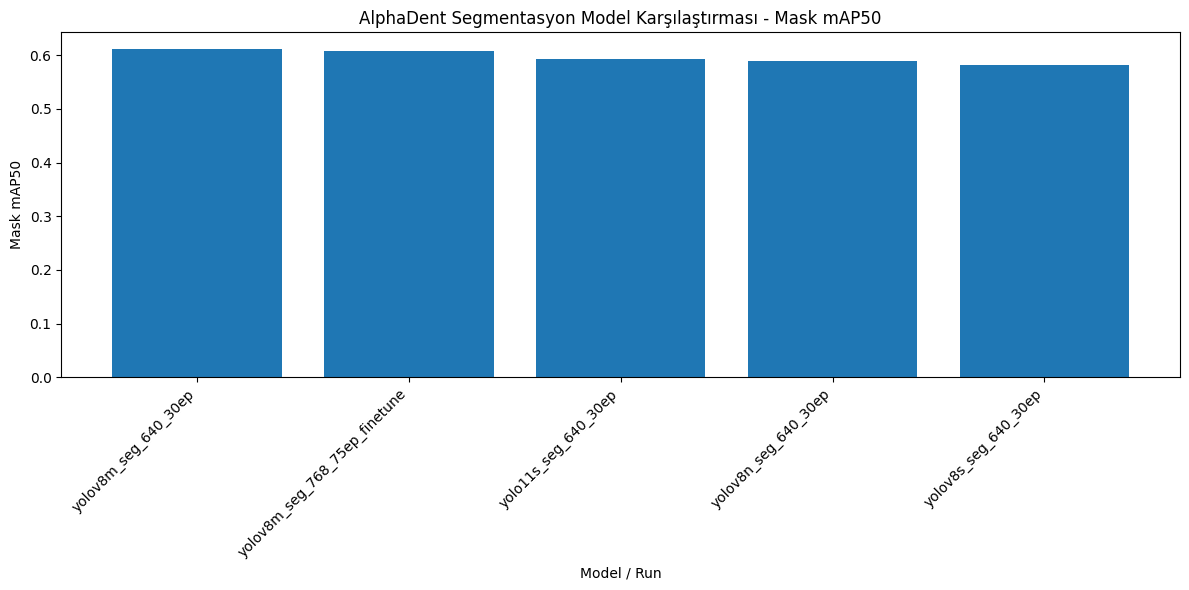

In [29]:
plot_df = df_alphadent_comparison.copy()

plt.figure(figsize=(12, 6))
plt.bar(plot_df["run_name"], plot_df["mask_mAP50"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Model / Run")
plt.ylabel("Mask mAP50")
plt.title("AlphaDent Segmentasyon Model Karşılaştırması - Mask mAP50")
plt.tight_layout()
plt.show()

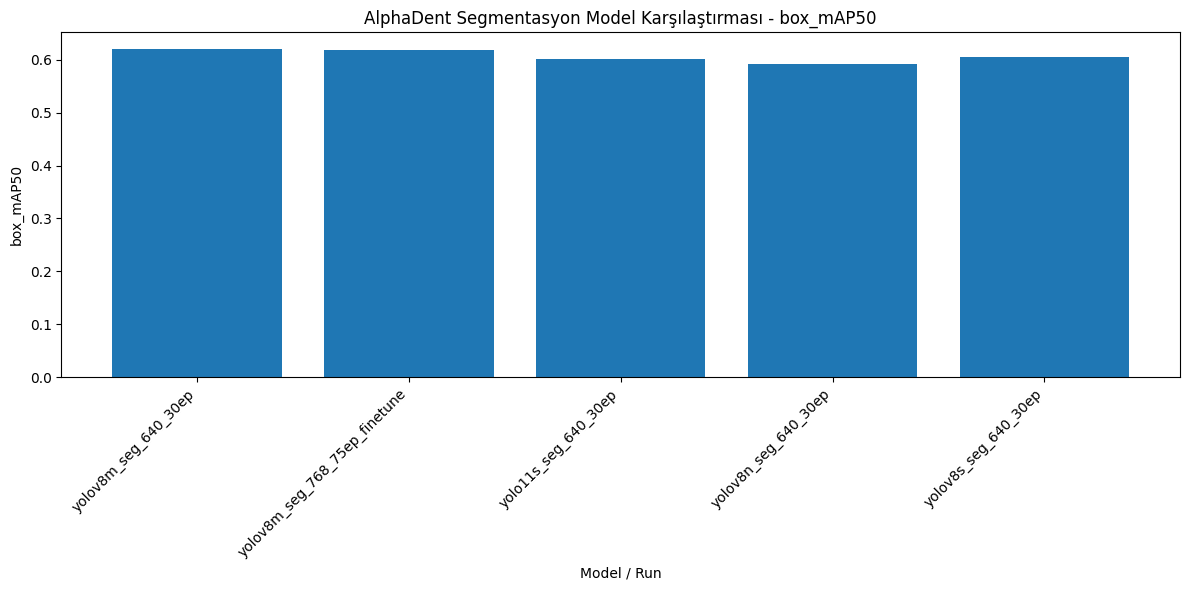

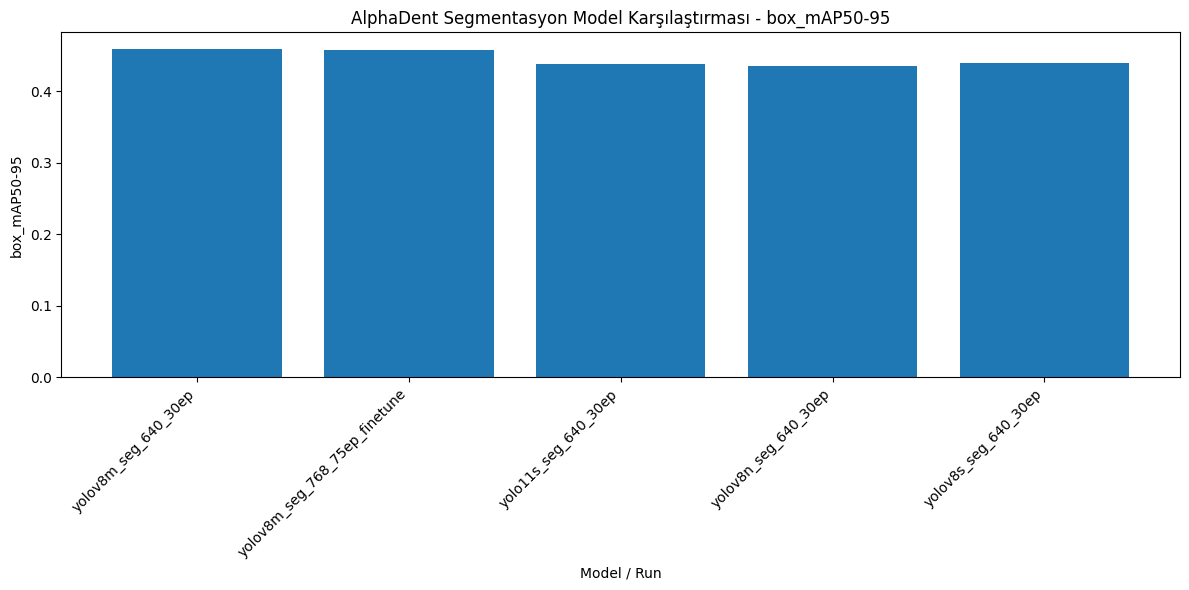

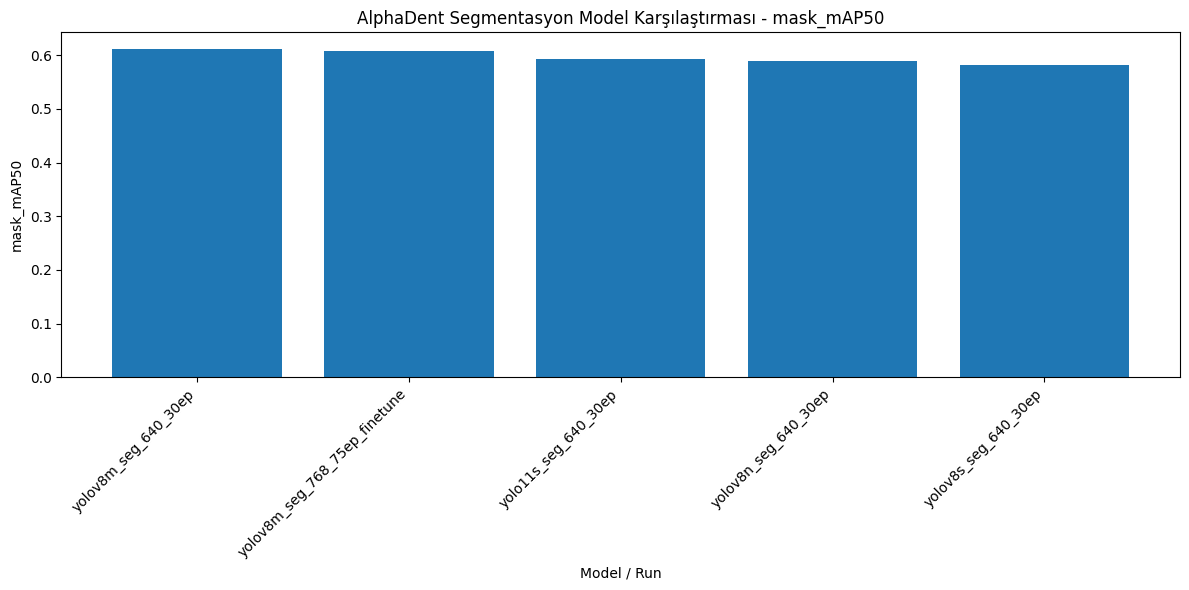

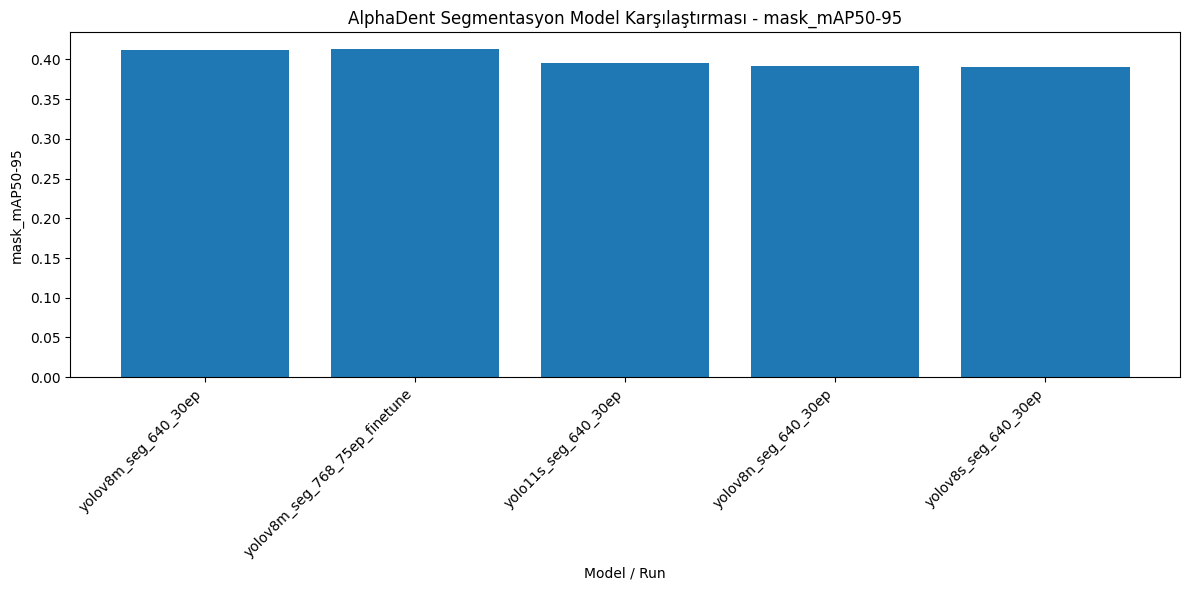

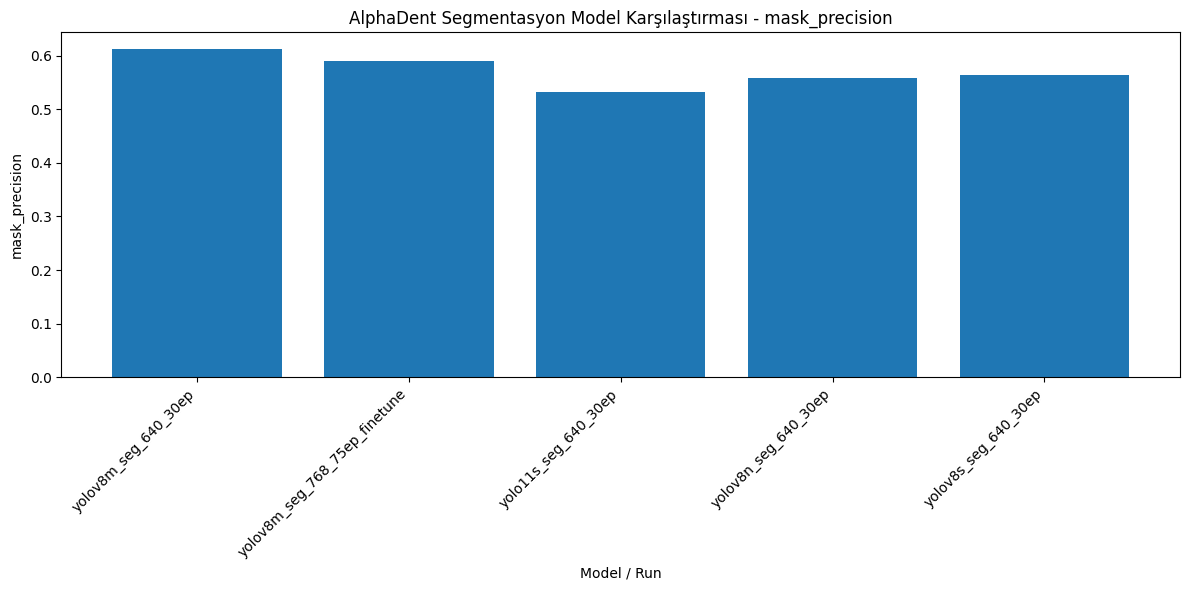

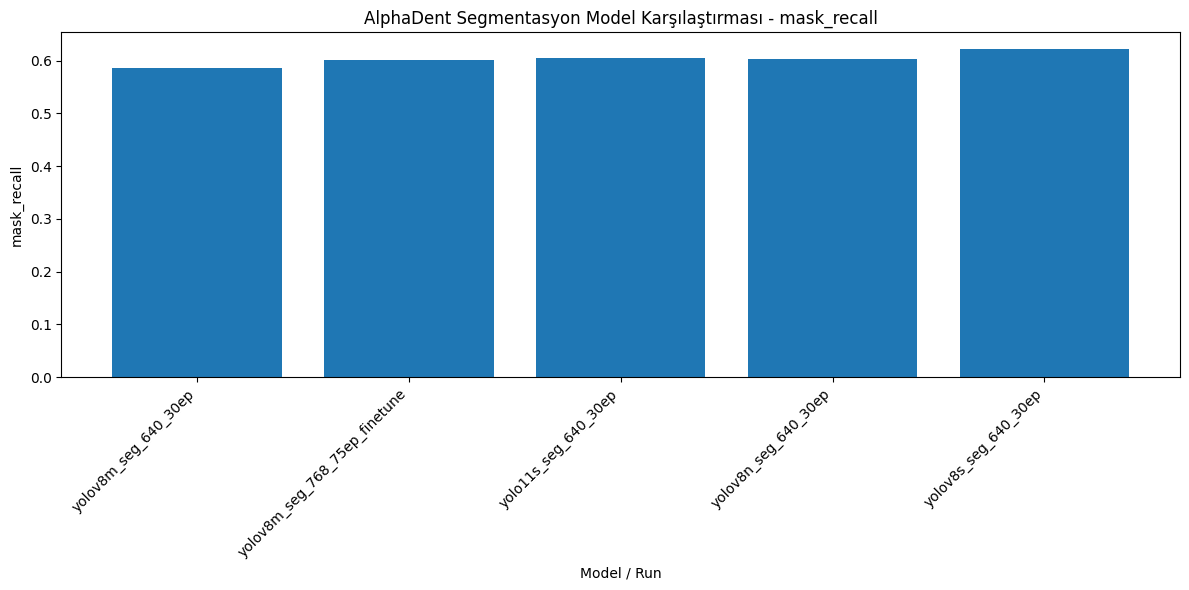

In [30]:
plot_df = df_alphadent_comparison.copy()

metrics = [
    "box_mAP50",
    "box_mAP50-95",
    "mask_mAP50",
    "mask_mAP50-95",
    "mask_precision",
    "mask_recall"
]

for metric in metrics:
    plt.figure(figsize=(12, 6))
    plt.bar(plot_df["run_name"], plot_df[metric])
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Model / Run")
    plt.ylabel(metric)
    plt.title(f"AlphaDent Segmentasyon Model Karşılaştırması - {metric}")
    plt.tight_layout()
    plt.show()

In [31]:
best = df_alphadent_comparison.iloc[0]

comment = f"""
AlphaDent veri seti üzerinde YOLOv8n-seg, YOLOv8s-seg, YOLOv8m-seg ve YOLO11s-seg modelleri
30 epoch boyunca eğitilerek karşılaştırılmıştır. İlk tur deneylerinde en iyi sonuç YOLOv8m-seg modeliyle
elde edilmiştir. YOLOv8m-seg 640 görüntü boyutu ve 30 epoch ayarında mask_mAP50=0.6121 ve
mask_mAP50-95=0.4115 değerlerine ulaşmıştır.

Daha sonra ilk turda en iyi çıkan YOLOv8m-seg modeli, daha yüksek görüntü boyutu ve daha uzun eğitim süresiyle
yeniden eğitilmiştir. Genel karşılaştırmada en iyi sonuç {best['model']} modelinin {best['run_name']} deneyinde
elde edilmiştir. Bu deneyde mask_mAP50={best['mask_mAP50']:.4f} ve mask_mAP50-95={best['mask_mAP50-95']:.4f}
olarak hesaplanmıştır.

AlphaDent veri setinde modeller, ağız içi görüntüler üzerinde diş çürüğü ve diş aşınması bölgelerini segmentasyon
tabanlı olarak ayırmayı hedeflemiştir. Bu veri seti, polygon anotasyonları içerdiği için projenin mikro/yüzey hasarı
tespiti hedefi açısından en uygun veri setlerinden biridir.
"""

print(comment)


AlphaDent veri seti üzerinde YOLOv8n-seg, YOLOv8s-seg, YOLOv8m-seg ve YOLO11s-seg modelleri
30 epoch boyunca eğitilerek karşılaştırılmıştır. İlk tur deneylerinde en iyi sonuç YOLOv8m-seg modeliyle
elde edilmiştir. YOLOv8m-seg 640 görüntü boyutu ve 30 epoch ayarında mask_mAP50=0.6121 ve
mask_mAP50-95=0.4115 değerlerine ulaşmıştır.

Daha sonra ilk turda en iyi çıkan YOLOv8m-seg modeli, daha yüksek görüntü boyutu ve daha uzun eğitim süresiyle
yeniden eğitilmiştir. Genel karşılaştırmada en iyi sonuç YOLOv8m-seg modelinin yolov8m_seg_640_30ep deneyinde
elde edilmiştir. Bu deneyde mask_mAP50=0.6121 ve mask_mAP50-95=0.4115
olarak hesaplanmıştır.

AlphaDent veri setinde modeller, ağız içi görüntüler üzerinde diş çürüğü ve diş aşınması bölgelerini segmentasyon
tabanlı olarak ayırmayı hedeflemiştir. Bu veri seti, polygon anotasyonları içerdiği için projenin mikro/yüzey hasarı
tespiti hedefi açısından en uygun veri setlerinden biridir.



In [32]:
comment_path = RESULTS_DIR / "alphadent_seg_model_comparison_comment.txt"

comment_path.write_text(comment, encoding="utf-8")

print("Yorum kaydedildi:")
print(comment_path)

Yorum kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/results/alphadent_training/alphadent_seg_model_comparison_comment.txt


In [33]:
print("06B AlphaDent devam notebooku tamamlandı.")
print("=" * 100)

print("Seçilen final AlphaDent modeli:")
print(selected_best_target)

print("\nTüm modeller + final karşılaştırma:")
display(df_alphadent_comparison)

print("\nRapor tablosu:")
display(df_alphadent_report_table)

print("\nİlk tur vs final:")
display(df_compare_final)

06B AlphaDent devam notebooku tamamlandı.
Seçilen final AlphaDent modeli:
/content/drive/MyDrive/DIS_PROJESI_007/final_models/alphadent/alphadent_selected_best_yolov8m_seg_640_30ep.pt

Tüm modeller + final karşılaştırma:


,model,weights,run_name,imgsz,epochs,batch,box_precision,box_recall,box_mAP50,box_mAP50-95,mask_precision,mask_recall,mask_mAP50,mask_mAP50-95
0,YOLOv8m-seg,yolov8m-seg.pt,yolov8m_seg_640_30ep,640,30,4,0.578482,0.623575,0.620584,0.459795,0.613126,0.585585,0.612124,0.411457
1,YOLOv8m-seg,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,yolov8m_seg_768_75ep_finetune,768,75,4,0.530670,0.639962,0.617483,0.457998,0.591057,0.601421,0.608167,0.413483
2,YOLO11s-seg,yolo11s-seg.pt,yolo11s_seg_640_30ep,640,30,8,0.558936,0.588657,0.601638,0.438696,0.531689,0.605506,0.593423,0.395781
3,YOLOv8n-seg,yolov8n-seg.pt,yolov8n_seg_640_30ep,640,30,8,0.553011,0.600889,0.592514,0.435657,0.559407,0.602827,0.589347,0.391522
4,YOLOv8s-seg,yolov8s-seg.pt,yolov8s_seg_640_30ep,640,30,8,0.569006,0.620811,0.605136,0.439920,0.563801,0.622749,0.582481,0.390327



Rapor tablosu:


,model,architecture_type,model_size,task,imgsz,epochs,batch,box_precision,box_recall,box_mAP50,box_mAP50-95,mask_precision,mask_recall,mask_mAP50,mask_mAP50-95,run_name,description
0,YOLOv8m-seg,YOLO instance segmentation,medium,instance segmentation,640,30,4,0.578482,0.623575,0.620584,0.459795,0.613126,0.585585,0.612124,0.411457,yolov8m_seg_640_30ep,Daha yüksek kapasiteye sahip YOLOv8 segmentasy...
1,YOLOv8m-seg,YOLO instance segmentation,medium,instance segmentation,768,75,4,0.530670,0.639962,0.617483,0.457998,0.591057,0.601421,0.608167,0.413483,yolov8m_seg_768_75ep_finetune,Daha yüksek kapasiteye sahip YOLOv8 segmentasy...
2,YOLO11s-seg,YOLO instance segmentation,small,instance segmentation,640,30,8,0.558936,0.588657,0.601638,0.438696,0.531689,0.605506,0.593423,0.395781,yolo11s_seg_640_30ep,Güncel YOLO ailesinden küçük ölçekli segmentas...
3,YOLOv8n-seg,YOLO instance segmentation,nano,instance segmentation,640,30,8,0.553011,0.600889,0.592514,0.435657,0.559407,0.602827,0.589347,0.391522,yolov8n_seg_640_30ep,Hızlı ve hafif YOLOv8 segmentasyon modeli
4,YOLOv8s-seg,YOLO instance segmentation,small,instance segmentation,640,30,8,0.569006,0.620811,0.605136,0.439920,0.563801,0.622749,0.582481,0.390327,yolov8s_seg_640_30ep,Hız ve başarı dengesi için kullanılan YOLOv8 s...



İlk tur vs final:


,status,model,weights,run_name,imgsz,epochs,batch,box_precision,box_recall,box_mAP50,box_mAP50-95,mask_precision,mask_recall,mask_mAP50,mask_mAP50-95,best_model_path,error
0,ok,YOLOv8m-seg,yolov8m-seg.pt,yolov8m_seg_640_30ep,640,30,4,0.578482,0.623575,0.620584,0.459795,0.613126,0.585585,0.612124,0.411457,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,
1,ok,YOLOv8m-seg,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,yolov8m_seg_768_75ep_finetune,768,75,4,0.530670,0.639962,0.617483,0.457998,0.591057,0.601421,0.608167,0.413483,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,
